In [1]:
!pip install langgraph

In [9]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [3]:
class batsmanstate(TypedDict):
  runs: int
  balls: int
  fours: int
  sixes: int

  sr: float
  bpb: float
  boundary_percentage: float
  summary: str

In [6]:
# function for strike rate

def cal_sr(state: batsmanstate) -> batsmanstate:
  sr = (state['runs']/state['balls'])*100
  # returning the dictionary
  return {'sr': sr}

In [7]:
# function for bpb

def cal_bpb(state: batsmanstate)-> batsmanstate:
  bpb = state['balls']/(state['fours']+state['sixes'])
  return {'bpb': bpb}

In [8]:
# function for boundary percentage

def cal_b_p(state: batsmanstate) -> batsmanstate:
  boundary_percentage = (((state['fours']*4)+(state['sixes']*6))/state['runs'])*100
  return {'boundary_percentage': boundary_percentage}

In [15]:
# function for summary

def gen_summ(state: batsmanstate)-> batsmanstate:

  summary = f"""
  strike_rate: {state['sr']} \n
  balls_per_boundary: {state['bpb']} \n
  boundary_percentage: {state['boundary_percentage']}
  """
  return {'summary': summary}

In [13]:
graph = StateGraph(batsmanstate)

# node
graph.add_node("calculating_sr", cal_sr)
graph.add_node("calculating_bpb", cal_bpb)
graph.add_node("calculating_boundaryp", cal_b_p)
graph.add_node("generating_summary", gen_summ)

# edges
graph.add_edge(START, "calculating_sr")
graph.add_edge(START, "calculating_bpb")
graph.add_edge(START, "calculating_boundaryp")

graph.add_edge("calculating_sr", "generating_summary")
graph.add_edge("calculating_bpb", "generating_summary")
graph.add_edge("calculating_boundaryp", "generating_summary")

graph.add_edge("generating_summary", END)

# compiling the graph
workflow = graph.compile()

In [16]:
# executing
initial_state = {'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4}
output_state = workflow.invoke(initial_state)

In [17]:
print(output_state)

{'runs': 100, 'balls': 50, 'fours': 6, 'sixes': 4, 'sr': 200.0, 'bpb': 5.0, 'boundary_percentage': 48.0, 'summary': '\n  strike_rate: 200.0,\n  balls_per_boundary: 5.0,\n  boundary_percentage: 48.0\n  '}


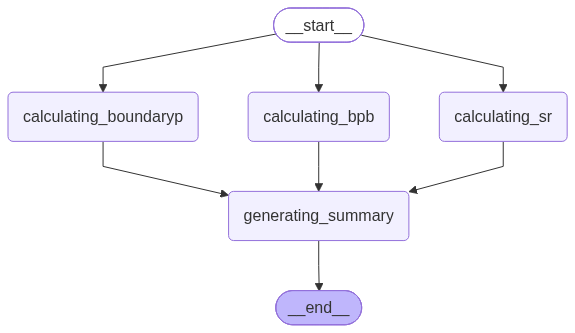

In [18]:
# visualization
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())